# プログラムの確からしさを確認するノートブック
## アノテーションのプログラムに間違いがないことを確認する


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob


In [8]:
img_files = glob.glob('./projects/project_20250704_104014/annotated/data_collection/images/train/*.jpg')
img_files

['./projects/project_20250704_104014/annotated/data_collection/images/train/snap_2025-07-04_10-41-20.jpg',
 './projects/project_20250704_104014/annotated/data_collection/images/train/snap_2025-07-04_10-41-31.jpg']

In [9]:
label_files = glob.glob('./projects/project_20250704_104014/annotated/data_collection/labels/train/*.txt')
label_files

['./projects/project_20250704_104014/annotated/data_collection/labels/train/snap_2025-07-04_10-41-20.txt',
 './projects/project_20250704_104014/annotated/data_collection/labels/train/snap_2025-07-04_10-41-31.txt']

In [10]:
img_file = img_files[0]
label_file = label_files[0]
img_file, label_file

('./projects/project_20250704_104014/annotated/data_collection/images/train/snap_2025-07-04_10-41-20.jpg',
 './projects/project_20250704_104014/annotated/data_collection/labels/train/snap_2025-07-04_10-41-20.txt')

In [11]:
# imgに対して、ラベルを描画する
def draw_labels_on_image(img_file, label_file):
    img = cv2.imread(img_file)
    with open(label_file, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:])
        
        # YOLO形式から座標を計算
        h, w = img.shape[:2]
        x1 = int((x_center - width / 2) * w)
        y1 = int((y_center - height / 2) * h)
        x2 = int((x_center + width / 2) * w)
        y2 = int((y_center + height / 2) * h)
        
        # ラベルを描画
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, str(class_id), (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    return img

In [12]:
annotated_img = draw_labels_on_image(img_file, label_file)
annotated_img

array([[[137, 135, 135],
        [137, 135, 135],
        [137, 135, 135],
        ...,
        [137, 135, 135],
        [137, 135, 135],
        [137, 135, 135]],

       [[137, 135, 135],
        [137, 135, 135],
        [137, 135, 135],
        ...,
        [137, 135, 135],
        [137, 135, 135],
        [137, 135, 135]],

       [[137, 135, 135],
        [137, 135, 135],
        [137, 135, 135],
        ...,
        [137, 135, 135],
        [137, 135, 135],
        [137, 135, 135]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

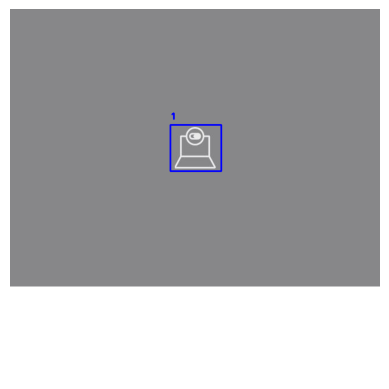

In [13]:
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

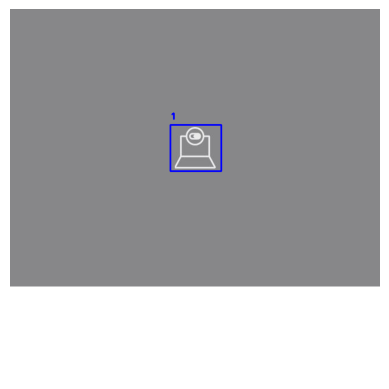

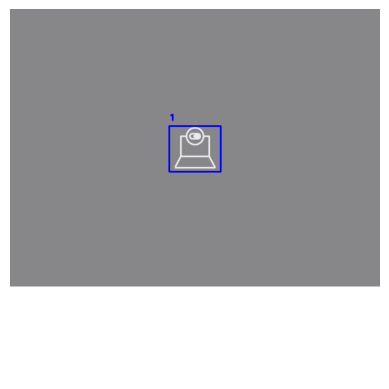

In [14]:
for img_file, label_file in zip(img_files, label_files):
    annotated_img = draw_labels_on_image(img_file, label_file)
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()